**Lecturer Note**  
This is not a data science course so we will move over the feature engineering and model training rather quickly.  
This is also the reason for why we are using the titanic dataset and not a more "business relevant" dataset, such as e.g. churn prediction.  

## Modelling challenge

Okay we have gotten a task from the boss/client.  
We need to predict titanic survivors using the Titanic - Machine Learning from Disaster Kaggle competition dataset.  
Should be simple enough, we have done plenty of classification projects before.  
Let's install the usual python packages for this sort of project.

In [59]:
%pip install catboost matplotlib pandas scikit-learn kaggle optuna ipywidgets kaleido shap jupyterlab-rise plotly

Note: you may need to restart the kernel to use updated packages.


Okay assuming we have set up a kaggle account and downloaded a kaggle.json token file to either .kaggle in the user directory or to the current directory in case of running in a github codespace.
We can simply run the cell below to download titanic dataset into the data folder.  
Alternatively just download dataset from kaggle manually.  
Usually we have a data engineer that gives us this data and uploads to some central location that is available to us.

In [46]:

import os
from pathlib import Path
container_check = os.getenv("iscontainer")
if container_check=="y":
    config_dir = Path("c:/Users/treal/.kaggle")
    config_dir.mkdir(parents=True, exist_ok=True)
    
    with open(config_dir / "kaggle.json", "w") as dst:
        with open("./kaggle.json", "r") as src:
            dst.write(src.read())


In [47]:
import os
import zipfile
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

# dataset = "student-habits-vs-academic-performance"
# dataset_test = "jayaantanaath/student-habits-vs-academic-performance"
# download_folder = Path("data/student-habits-vs-academic-performance")
# zip_path = download_folder / "student-habits-vs-academic-performance.zip"
# download_folder.mkdir(parents=True, exist_ok=True)

# api.competition_download_files(dataset, path=str(download_folder))
# api.dataset_download_files(dataset_test, path=str(download_folder), unzip=True)

dataset_name = "jayaantanaath/student-habits-vs-academic-performance" #tutaj wpisuje baze
download_folder = Path("data/student-habits-vs-academic-performance") #tutaj bedzie folder w ktorym bedzie dane
download_folder.mkdir(parents=True, exist_ok=True)

api.dataset_download_files(dataset_name, path=str(download_folder), unzip=True)


# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall(str(download_folder))
# os.remove(zip_path)

Dataset URL: https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance


Let's take a look at the data folder:

In [48]:
!dir "./data/student-habits-vs-academic-performance"

 Volume in drive C has no label.
 Volume Serial Number is 67A3-0D30

 Directory of c:\Users\treal\Desktop\MLOPS_ASESSMENT_1\notebooks\data\student-habits-vs-academic-performance

26.07.2025  20:11    <DIR>          .
26.07.2025  19:52    <DIR>          ..
26.07.2025  20:11            73�663 student_habits_performance.csv
               1 File(s)         73�663 bytes
               2 Dir(s)  36�541�038�592 bytes free


Perfect, so the data is in place and we can take a look at it, putting aside the PassengerId column since that is not going to be trained on.

In [49]:
import pandas as pd

df_train = pd.read_csv(download_folder / "student_habits_performance.csv")
df_ids = df_train.pop("student_id")  # set aside student_id

df_train.sample(10)

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
604,23,Other,3.1,2.8,2.0,No,100.0,6.8,Poor,4,Master,Good,8,Yes,72.8
485,22,Female,4.1,1.6,0.6,No,73.1,5.5,Fair,5,High School,Good,1,No,77.5
650,23,Female,2.8,2.4,0.7,No,78.6,8.2,Fair,0,Bachelor,Good,5,No,61.5
5,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
947,24,Female,4.5,3.2,3.3,Yes,70.0,6.3,Good,0,High School,Good,6,Yes,59.9
807,17,Female,3.3,1.8,0.0,No,70.3,4.7,Poor,2,High School,Average,7,Yes,65.2
539,18,Male,3.8,4.1,1.6,No,100.0,7.2,Good,4,NaN,Good,6,Yes,81.0
182,22,Male,4.2,3.1,0.7,No,69.2,7.2,Good,1,Master,Poor,10,No,79.9
538,21,Male,4.3,3.2,2.8,No,83.3,4.3,Poor,2,High School,Poor,6,No,67.5
605,19,Male,2.2,3.5,1.8,No,100.0,3.3,Good,6,Bachelor,Good,8,No,67.6


## Data overview
Okay we have been given the following data dictionary: 

Target is **"Survived"**, whether the passenger survived the sinking.  
* **PClass**: Passenger Ticket Class, either 1, 2, 3 for 1st, 2nd, 3rd class. Categorical.
* **Name**: Name of the passenger. Not usable raw.
* **Sex**: Sex of the passenger. Categorical.
* **Age**: Age of the passenger, fractional if less than 1, if estimated then in the form of xx.5. Numerical, candidate for binning into age groups.
* **SibSp**: Number of siblings/spouses aboard. Numerical.
* **parch**: Number of parents/children aboard. Numerical.
* **ticket**: Ticket number. Not usable raw. Unclear if usable at all.  
* **fare**: How much paid for the ticket. Numerical.
* **cabin**: Cabin number. Not usable raw. 
* **embarked**: Port of embarkation, either C = Cherbourg, Q = Queenstown, S = Southampton. Categorical.  

And the data looks like this when it comes to missing data:

In [50]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

The cabin column is mostly null so we will drop the column.  
Also we are not sure how to use the name since it is a string type with many, presumably all unique values, so can't just consider it a categorical value, so let's also drop that one for now.  
Finally the ticket serial number is not usable either. 

In [51]:
df_train = df_train.drop(columns=["parental_education_level"])
df_train.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Good,1,No,66.4


In [53]:
df_train['pass'] = (df_train['exam_score']>80).astype(int)

In [38]:
df_train.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,internet_quality,mental_health_rating,extracurricular_participation,pass
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Average,8,Yes,0
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,Average,8,No,1
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,Poor,1,No,0
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Good,1,Yes,0
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Good,1,No,0


In [54]:
categorical = [
    "gender", 
    "part_time_job", 
    "diet_quality" ,
    "internet_quality" ,
    "extracurricular_participation" ,
]

y_train = df_train.pop("pass")
X_train = df_train

categorical_indices = [X_train.columns.get_loc(col) for col in categorical if col in X_train.columns]
categorical_indices

[1, 5, 8, 10, 12]

And verifying that there are now no nulls

In [55]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  internet_quality               1000 non-null   object 
 11  mental_health_rating           1000 non-null   int64  
 12  extracurricular_participation  1000 non-null   ob

Okay now we need to choose the best parameters for training the model.  
Using optuna to easily set up a study, with typical ranges for the parameters.  
Then run the study and save the best parameters.  
Also putting in an if-else to check for existing file to not run again unnecessarily.

In [66]:
import joblib
import optuna
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool, cv

outfolder = Path("..\\results")
outfolder.mkdir(parents=True, exist_ok=True)

best_params_path = outfolder / "best_params.pkl"

if not best_params_path.is_file():
    X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(X_train, y_train, test_size=0.25, random_state=42)
    
    def objective(trial):
        params = {
            "depth": trial.suggest_int("depth", 2, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.3),
            "iterations": trial.suggest_int("iterations", 100, 300),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-5, 100.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.01, 1),
            "random_strength": trial.suggest_float("random_strength", 1e-5, 100.0, log=True)
        }
        model = CatBoostClassifier(**params, verbose=0)
        model.fit(X_train_opt, y_train_opt, eval_set=(X_val_opt, y_val_opt), cat_features=categorical_indices, early_stopping_rounds=50)
        return model.get_best_score()["validation"]["Logloss"]
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)
    
    joblib.dump(study.best_params, best_params_path)
    params = study.best_params
else:
    params = joblib.load(best_params_path)
print("Best Parameters:", params)

Best Parameters: {'depth': 5, 'learning_rate': 0.206817621789707, 'iterations': 1040, 'l2_leaf_reg': 7.271073192658653, 'bagging_temperature': 0.9829608555536249, 'random_strength': 0.590694033357288}


Okay now we have the optimal hyperparameters for training our model.  
Let's train the model using cross validation to get a better idea of the performance.  
Given the lack of data we are not setting aside a test set.  
Setting metric to F1 to optimize both Precision and Recall and save results to file.  

In [71]:
params["eval_metric"] = "F1"
params["loss_function"] = "Logloss"

model = CatBoostClassifier(
    **params,
    verbose=True
)

data = Pool(X_train, y_train, cat_features=categorical_indices)

cv_results = cv(
    params=params,
    pool=data,
    fold_count=5,
    partition_random_seed=42,
    shuffle=True,
)
os.makedirs(outfolder, exist_ok=True)
cv_results.to_csv(outfolder / "cv_results.csv", index=False)

Training on fold [0/5]
0:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 28.6ms	remaining: 29.7s
1:	learn: 0.9954751	test: 1.0000000	best: 1.0000000 (0)	total: 41.1ms	remaining: 21.3s
2:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 59.7ms	remaining: 20.6s
3:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 73.4ms	remaining: 19s
4:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 91.5ms	remaining: 18.9s
5:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 105ms	remaining: 18.2s
6:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 125ms	remaining: 18.5s
7:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 141ms	remaining: 18.2s
8:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 159ms	remaining: 18.2s
9:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 174ms	remaining: 18s
10:	learn: 0.9977221	test: 1.0000000	best: 1.0000000 (0)	total: 195ms	remaining: 18.3s
11:	learn: 0.9977221	test: 1.

Let's plot test performance during training.

In [75]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add mean performance line
fig.add_trace(
    go.Scatter(
        x=cv_results["iterations"], y=cv_results["test-F1-mean"], mode="lines", name="Mean F1 Score", line=dict(color="blue")
    )
)

# Add shaded error region
fig.add_trace(
    go.Scatter(
        x=pd.concat([cv_results["iterations"], cv_results["iterations"][::-1]]),
        y=pd.concat([cv_results["test-F1-mean"]+cv_results["test-F1-std"], 
                     cv_results["test-F1-mean"]-cv_results["test-F1-std"]]),
        fill="toself", 
        fillcolor="rgba(0, 0, 255, 0.2)",
        line=dict(color="rgba(255, 255, 255, 0)"),
        showlegend=False
    )
)

# Customize layout
fig.update_layout(
    title="Cross-Validation (N=5) Mean F1 score with Error Bands",
    xaxis_title="Training Steps",
    yaxis_title="Performance Score",
    template="plotly_white",
    yaxis=dict(range=[0.5, 1])
)

fig.show()

#fig.write_image(outfolder / "test_f1.png")

In [76]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add mean performance line
fig.add_trace(
    go.Scatter(
        x=cv_results["iterations"], y=cv_results["test-Logloss-mean"], mode="lines", name="Mean logloss", line=dict(color="blue")
    )
)

# Add shaded error region
fig.add_trace(
    go.Scatter(
        x=pd.concat([cv_results["iterations"], cv_results["iterations"][::-1]]),
        y=pd.concat([cv_results["test-Logloss-mean"]+cv_results["test-Logloss-std"], 
                     cv_results["test-Logloss-mean"]-cv_results["test-Logloss-std"]]),
        fill="toself", 
        fillcolor="rgba(0, 0, 255, 0.2)",
        line=dict(color="rgba(255, 255, 255, 0)"),
        showlegend=False
    )
)

# Customize layout
fig.update_layout(
    title="Cross-Validation (N=5) Mean Logloss with Error Bands",
    xaxis_title="Training Steps",
    yaxis_title="Logloss",
    template="plotly_white"
)

fig.show()

#fig.write_image(outfolder / "test_logloss.png")

Okay these plots look reasonable enough, clearly we are betting than a coin-flip, so good enough for an initial model.  
Finally we can train a model on the full dataset and performance should equal the cross validation performance.

In [77]:
model.fit(
    X_train,
    y_train,
    verbose_eval=50,
    early_stopping_rounds=50,
    cat_features=categorical_indices,
    use_best_model=False,
    plot=True
)

model.save_model(outfolder / 'catboost_model_students_habits_performance.cbm')
joblib.dump(params, outfolder / 'model_params.pkl')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.9908592	total: 16ms	remaining: 16.7s
50:	learn: 1.0000000	total: 925ms	remaining: 17.9s
100:	learn: 1.0000000	total: 1.86s	remaining: 17.3s
150:	learn: 1.0000000	total: 2.75s	remaining: 16.2s
200:	learn: 1.0000000	total: 3.65s	remaining: 15.3s
250:	learn: 1.0000000	total: 4.54s	remaining: 14.3s
300:	learn: 1.0000000	total: 5.47s	remaining: 13.4s
350:	learn: 1.0000000	total: 6.4s	remaining: 12.6s
400:	learn: 1.0000000	total: 7.3s	remaining: 11.6s
450:	learn: 1.0000000	total: 8.17s	remaining: 10.7s
500:	learn: 1.0000000	total: 9.07s	remaining: 9.76s
550:	learn: 1.0000000	total: 9.96s	remaining: 8.84s
600:	learn: 1.0000000	total: 10.8s	remaining: 7.91s
650:	learn: 1.0000000	total: 11.7s	remaining: 7.01s
700:	learn: 1.0000000	total: 12.6s	remaining: 6.1s
750:	learn: 1.0000000	total: 13.5s	remaining: 5.19s
800:	learn: 1.0000000	total: 14.4s	remaining: 4.28s
850:	learn: 1.0000000	total: 15.2s	remaining: 3.38s
900:	learn: 1.0000000	total: 16.1s	remaining: 2.48s
950:	learn: 1.00000

['..\\results\\model_params.pkl']

Great, that was a lot of work but now we have a trained model that is predicting better than chance saved to a model file.  
Now let's predict on the test set and create some shapley plots to convince people that our predictions make sense!

In [84]:
df_test = pd.read_csv( "c:\\Users\\treal\\desktop\\mlops_asessment_1\\notebooks\\data\\student_habits_test_25.csv")

In [85]:
df_test.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,internet_quality,mental_health_rating,extracurricular_participation,exam_score,pass
0,19,Male,5.9,1.5,0.7,Yes,83.8,9.2,Poor,6,Poor,1,Yes,37.5,0
1,18,Male,5.7,4.2,2.1,No,79.5,8.7,Poor,2,Good,7,No,42.2,0
2,21,Female,0.8,2.3,1.8,No,80.2,8.6,Good,7,Good,2,No,26.3,0
3,22,Female,4.6,4.2,0.2,Yes,88.7,9.9,Poor,1,Average,5,No,70.9,0
4,23,Male,3.0,1.3,1.3,Yes,80.5,4.2,Good,3,Poor,8,No,41.6,0


In [86]:
model.predict(df_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

Oh dear, that didnt work.  
Right, of course we have to do all the same preprocessing again in order to also create a proper test set for prediction.  
Let's copy the code from before but run it on the test set.  
Dropping the unused columns again and setting aside the PassengerId.

Filling in nulls using the same placeholder for embarked and mean age (train since we need to have a certain amount of data to construct the mean from). 

Making sure columns are in the right order, and then doing the prediction.

In [87]:
preds = model.predict(df_test)

Great now it works, but should we really be copy pasting code around?  
What if we want to change the preprocessing later?  
Anyways let's get the shapley values.

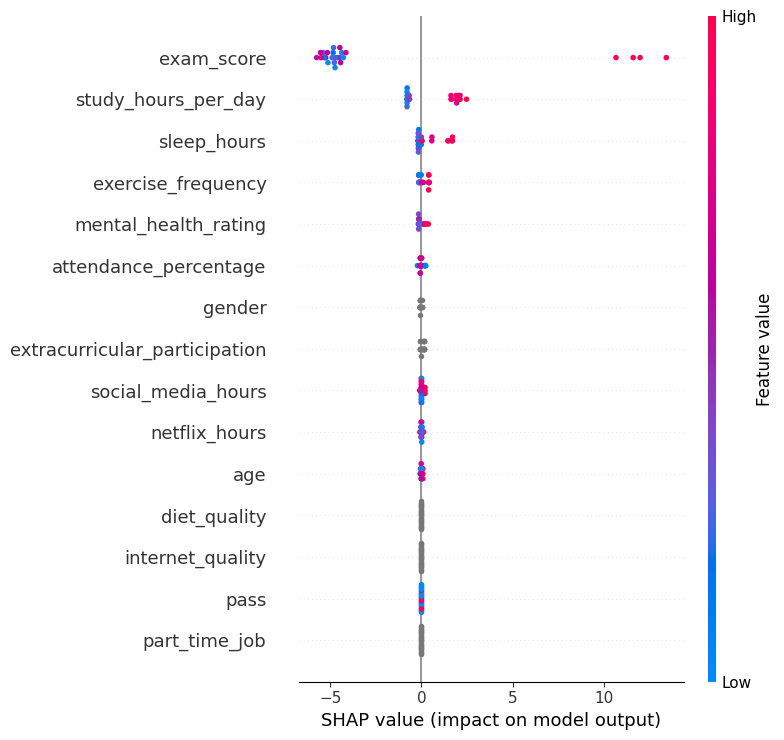

In [88]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df_test)

shap.summary_plot(shap_values, df_test, show=False)
plt.savefig(outfolder / "test_shap_overall.png")

Okay now we have something to look at to convince ourselves that the model is making sense.  
Finally let's save the predictions to a csv file as required by kaggle, so that we can get the final performance.

In [92]:
df_test["Student_id"] = df_test.index
df_test["pass"] = preds
df_test[["Student_id", "pass"]].to_csv(outfolder / "predictions.csv", index=False)

And submitting to kaggle we get the following performance which is what we would expect given our cross validation results:
  
![screenshot of kaggle submission page with prediction performance of 0.74880](results/kaggle_result.png "Kaggle Result")

All done and dusted, on to the next project right?  
Let's present to the client.